In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from sqlalchemy import create_engine
import pandas as pd
from sklearn.neural_network import MLPRegressor
import time

In [3]:
def get_data(datafile='data_3mdb.sql.gz', force=False):
    if not os.path.exists(datafile) or force:
        sel = """SELECT
                log10(O__3_500684A/H__1_486133A) as O3,  
                log10(N__2_658345A/H__1_486133A) as N2, 
                log10(BLND_372700A/H__1_486133A) as O2, 
                log10((NE_3_386876A + NE_3_396747A)/H__1_486133A) as Ne3,
                log10(AR_3_713579A/H__1_486133A) as Ar3,
                log10(HE_1_587564A/H__1_486133A) as He1,
                log10(BLND_436300A/O__3_500684A) as rO3,
                log10(BLND_575500A/N__2_658345A) as rN2,
                log10((S__2_673082A+S__2_671644A)/H__1_486133A) as S2,
                NITROGEN - OXYGEN as NO,
                CARBON - OXYGEN as CO,
                OXYGEN as O,
                logU_mean as logU,
                SUBSTRING(com3, 6) as age
                FROM tab_17
                WHERE ref = 'HII_24'
                AND HbFrac > 0.95
                AND atm_file = 'BPASSv2.2.1_bin-imf_chab300.mod'
                """
        user = os.environ['MdB_USER']
        passwd = os.environ['MdB_PASSWD']
        host = '132.248.3.52'
        db = '3MdB_17'
        port='3306'
        sqlEngine = create_engine(f'mysql+pymysql://{user}:{passwd}@{host}:{port}/{db}')
        with sqlEngine.connect() as db_con:
            res = pd.read_sql(sel, con=db_con)
        res['age'] = res['age'].astype('float64')
        res.to_csv(datafile, index=False)
    else:
        res = pd.read_csv(datafile)
    return res

In [4]:
data = get_data(force=False)
print(len(data))

267334


In [5]:
data.describe()

,O3,N2,O2,Ne3,Ar3,He1,rO3,rN2,S2,NO,CO,O,logU,age
count,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000
mean,-0.866664,-1.935690,-1.195440,-1.676165,-2.333604,-0.935771,-1.914134,-1.671712,-1.961232,-0.983929,-0.448540,-4.866357,-2.494576,4.000832
std,1.453207,1.573751,1.187134,1.293282,1.234573,0.115815,0.603583,0.390174,1.340001,0.911889,0.796102,1.336265,1.243617,1.732689
min,-13.114994,-7.773197,-5.799998,-12.632173,-13.222975,-1.596834,-5.170163,-4.100083,-6.932393,-3.492813,-2.757791,-8.253771,-5.822620,1.000041
25%,-1.694235,-3.045155,-2.050800,-2.375373,-3.242522,-1.010289,-2.070810,-1.744469,-2.934571,-1.733172,-1.093946,-5.997723,-3.518528,2.498024
50%,-0.686032,-1.826400,-1.040399,-1.524984,-2.164684,-0.956226,-1.765912,-1.561641,-1.826632,-0.984517,-0.456327,-4.874693,-2.511050,4.001179
75%,0.275544,-0.727181,-0.219810,-0.722061,-1.304892,-0.862422,-1.532702,-1.465879,-0.882603,-0.234604,0.191961,-3.745000,-1.488070,5.500586
max,2.164705,1.370001,1.045367,1.173552,0.192192,0.018957,-0.356966,1.396864,0.817752,1.486829,1.900643,-1.627291,2.362640,6.999976


In [ ]:
# We define once for all the names of the columns used as input and output of the ANN:
X_str = ["CO", "NO", "O", "logU", "age"]
y_str = ["O3", "N2", "O2", "rO3", "rN2", "S2", "Ar3", "Ne3", "He1"]

In [7]:
test_prop = 0.2 # 20% de la muestra de usara para pruebas. 80% para el entrenamiento
N = len(data)

if 'train' not in data.keys():
    data['train'] = np.where(np.random.rand(N) > test_prop, 1, 0 )


In [8]:
# Scale the inputs:
for s1 in X_str:
    data[s1 + '_sc'] = (data[s1] - np.min(data[s1])) / (np.max(data[s1]) - np.min(data[s1]))

In [9]:
data.describe()

,O3,N2,O2,Ne3,Ar3,He1,rO3,rN2,S2,NO,CO,O,logU,age,train,CO_sc,NO_sc,O_sc,logU_sc,age_sc
count,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000,267334.000000
mean,-0.866664,-1.935690,-1.195440,-1.676165,-2.333604,-0.935771,-1.914134,-1.671712,-1.961232,-0.983929,-0.448540,-4.866357,-2.494576,4.000832,0.800676,0.495714,0.503828,0.511194,0.406590,0.500137
std,1.453207,1.573751,1.187134,1.293282,1.234573,0.115815,0.603583,0.390174,1.340001,0.911889,0.796102,1.336265,1.243617,1.732689,0.399493,0.170895,0.183123,0.201655,0.151934,0.288785
min,-13.114994,-7.773197,-5.799998,-12.632173,-13.222975,-1.596834,-5.170163,-4.100083,-6.932393,-3.492813,-2.757791,-8.253771,-5.822620,1.000041,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-1.694235,-3.045155,-2.050800,-2.375373,-3.242522,-1.010289,-2.070810,-1.744469,-2.934571,-1.733172,-1.093946,-5.997723,-3.518528,2.498024,1.000000,0.357168,0.353367,0.340460,0.281493,0.249667
50%,-0.686032,-1.826400,-1.040399,-1.524984,-2.164684,-0.956226,-1.765912,-1.561641,-1.826632,-0.984517,-0.456327,-4.874693,-2.511050,4.001179,1.000000,0.494042,0.503710,0.509936,0.404577,0.500195
75%,0.275544,-0.727181,-0.219810,-0.722061,-1.304892,-0.862422,-1.532702,-1.465879,-0.882603,-0.234604,0.191961,-3.745000,-1.488070,5.500586,1.000000,0.633207,0.654306,0.680417,0.529556,0.750099
max,2.164705,1.370001,1.045367,1.173552,0.192192,0.018957,-0.356966,1.396864,0.817752,1.486829,1.900643,-1.627291,2.362640,6.999976,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
# The use of data.loc[train_loc, X_str_sca] allows to access the training data without duplicating anything.

# Define the list of scaled inputs:
X_str_sca = [s1 + '_sc' for s1 in X_str]

random_state = 42
train_loc = data['train'] == 1
test_loc = data['train'] == 0

In [ ]:
# Instantiation of the neural network
ANN = MLPRegressor(random_state=random_state, hidden_layer_sizes=(20,50,20,), 
                    tol=1e-6, max_iter=20000, activation='tanh', 
                    solver='adam', verbose=False)
# Training the neural network
ANN_fit = ANN.fit(X=data.loc[train_loc, X_str_sca], 
                  y=data.loc[train_loc, y_str])
# Time to train on Macbook: 5 minutes

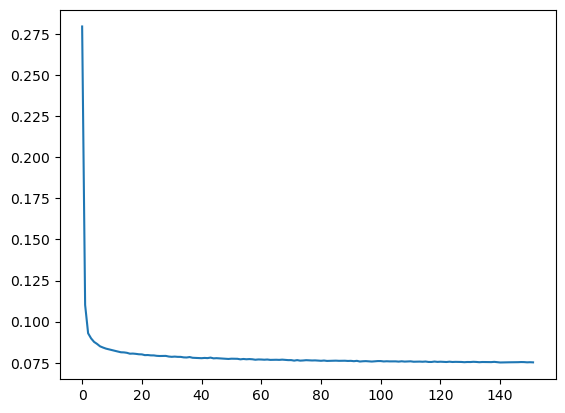

In [12]:
f, ax = plt.subplots()
ax.plot(ANN_fit.loss_curve_);

In [13]:
# Obtain the predictions for the test set
preds = ANN.predict(data.loc[test_loc, X_str_sca])

In [14]:
# Obtain the statistics for the predictions
for i, y in enumerate(y_str):
    diff = data.loc[test_loc, y].to_numpy() - preds[:,i]
    print(f'<{y:4s}> = {np.median(diff):5.2f} +/- {np.std(diff):.2f}')

<O3  > =  0.04 +/- 0.53
<N2  > =  0.02 +/- 0.35
<O2  > =  0.09 +/- 0.28
<rO3 > =  0.01 +/- 0.28
<rN2 > = -0.02 +/- 0.23
<S2  > =  0.07 +/- 0.39
<Ar3 > =  0.02 +/- 0.51
<Ne3 > =  0.03 +/- 0.52
<He1 > = -0.02 +/- 0.09


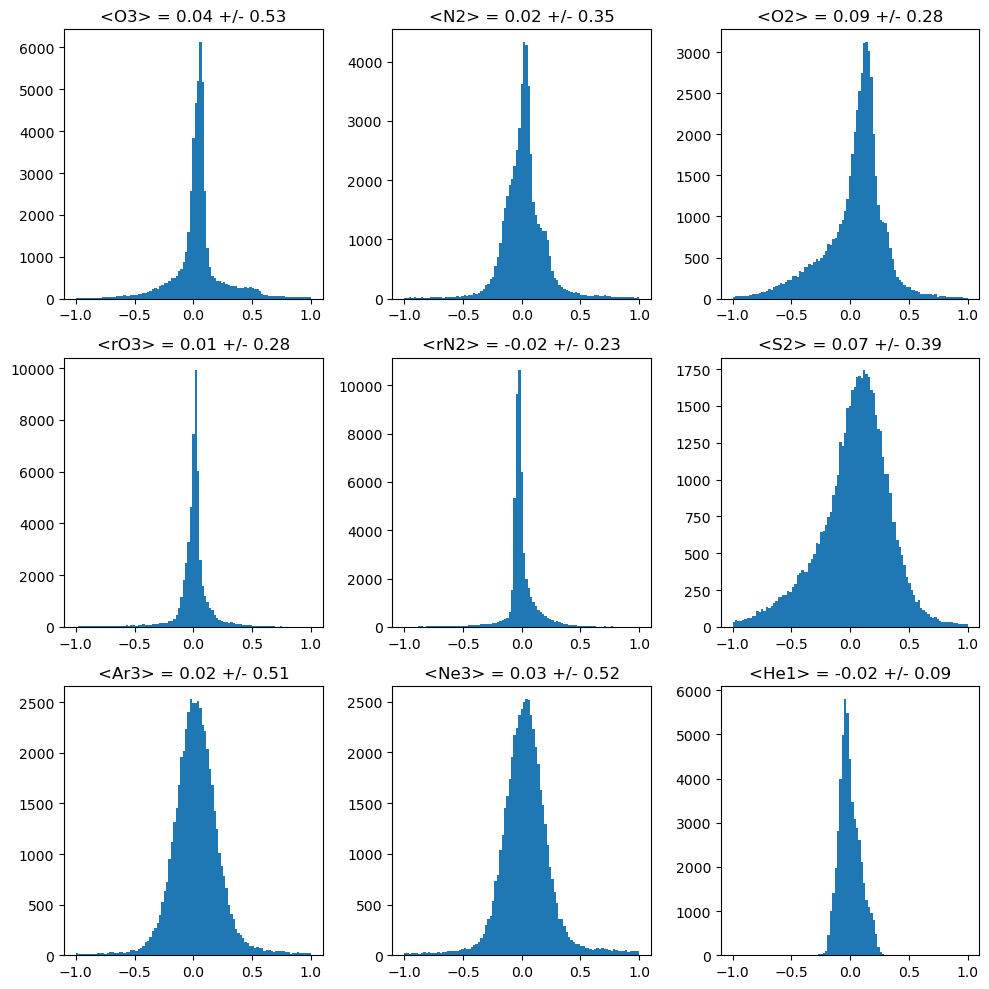

In [15]:
# Plot the distributions of the differences between predictions and real values
f, axes = plt.subplots(3,3, figsize=(10,10))

i = 0
for y, ax in zip(y_str, axes.ravel()):
    diff = data.loc[test_loc, y].to_numpy() - preds[:,i]
    aa = ax.hist(diff, bins=np.linspace(-1, 1, 100))
    ax.set_title(f'<{y}> = {np.median(diff):.2f} +/- {np.std(diff):.2f}')
    i += 1
plt.tight_layout()

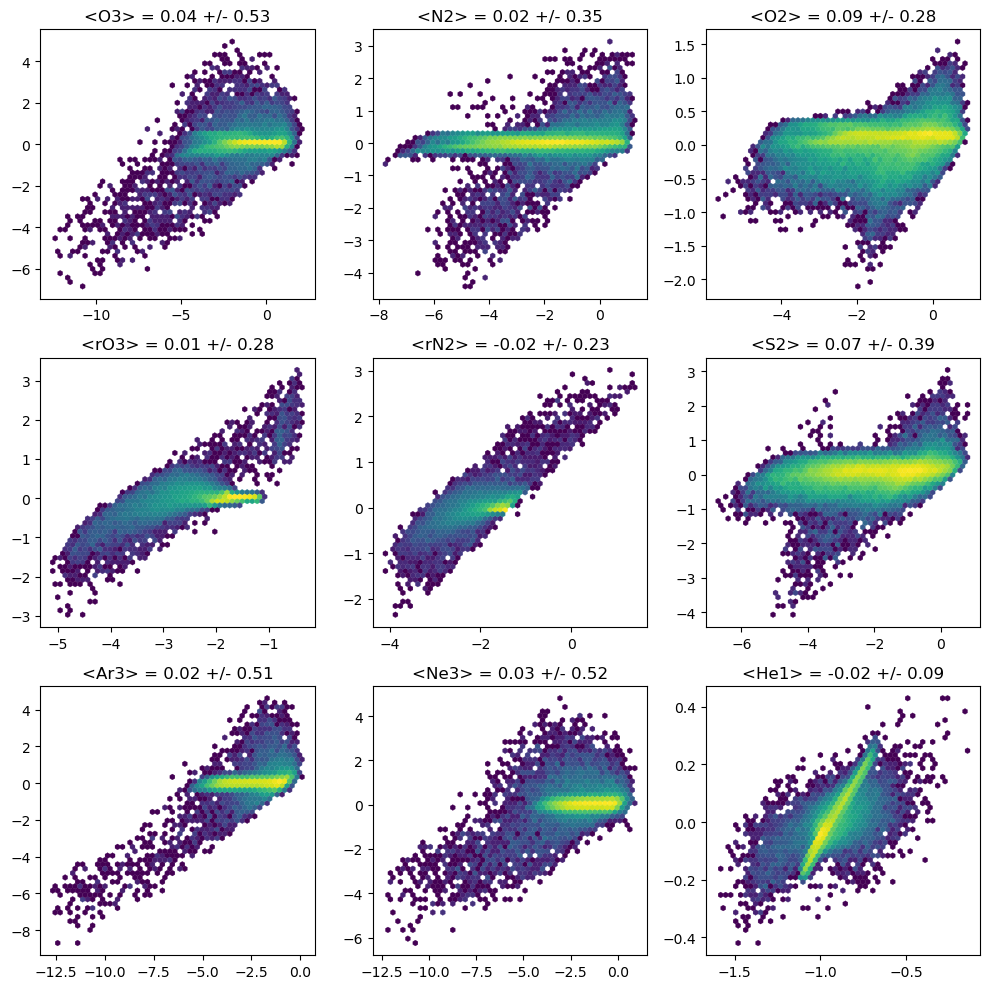

In [16]:
# This is a hexbin plot of the differences between the predicted and real values
f, axes = plt.subplots(3,3, figsize=(10,10))

i = 0
for y, ax in zip(y_str, axes.ravel()):
    diff = (data.loc[test_loc, y].to_numpy() - preds[:,i]) 
    aa = ax.hexbin(data.loc[test_loc, y].to_numpy(), diff, bins='log', gridsize=50, linewidths=0.2)
    ax.set_title(f'<{y}> = {np.median(diff):.2f} +/- {np.std(diff):.2f}')
    i += 1
plt.tight_layout()

In [27]:
# Generate N_rand inputs and make the corresponding predictions
start = time.time()
N_rand = 1000000
P = pd.DataFrame(np.random.rand(N_rand, len(X_str_sca)), columns=X_str_sca)
preds = pd.DataFrame(ANN.predict(P[X_str_sca]), columns=y_str)
end = time.time()
print(f'{N_rand} models done in {end-start:.3f}s: {(end-start)/N_rand:.3e}s / model')

1000000 models done in 6.128s: 6.128e-06s / model


In [48]:
# Select a target from the test set. We will determine the models that best fits this target.
i_target = 42 #221
target = data.loc[test_loc].iloc[i_target]
print(target)

O3        -1.677410
N2        -3.050454
O2        -0.885114
Ne3       -2.285390
Ar3       -2.754060
He1       -0.994760
rO3       -1.831505
rN2       -1.630096
S2        -1.723972
NO        -2.282690
CO        -1.391529
O         -5.592377
logU      -3.717800
age        4.453869
train      0.000000
CO_sc      0.293288
NO_sc      0.243014
O_sc       0.401630
logU_sc    0.257148
age_sc     0.575644
Name: 159, dtype: float64


In [49]:
# The list of lines to be used to find parameters that approach the "target".
#diff_str = ['O3', 'N2', 'O2', 'Ar3', 'Ne3', 'He1']
diff_str = ['O3', 'N2', 'O2', 'rO3']
diff_str = ['O3', 'N2', 'O2']
preds['mean'] = np.mean(np.abs((preds[diff_str] - target[diff_str])), 1)
preds['max'] = np.max(np.abs((preds[diff_str] - target[diff_str])), 1)

In [50]:
# We select the models that have a mean difference less than 0.15
best_diffs_loc = preds['mean'] < 0.15

In [51]:
print(best_diffs_loc.sum())

744


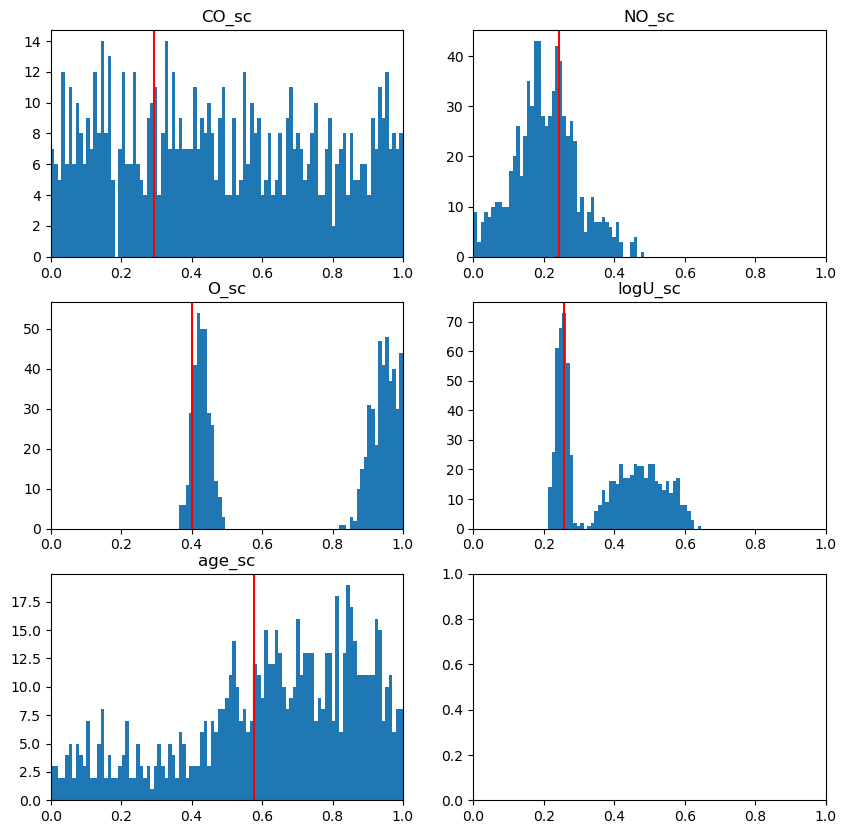

In [52]:
# We will plot the distributions of the parameters of the models that reproduce the observations.
f, axes = plt.subplots(3,2, figsize=(10,10))
for k, ax in zip(X_str_sca, axes.ravel()):
    ax.hist(P.loc[best_diffs_loc, k], bins=np.linspace(0,1,100))
    ax.set_xlim(0,1)
    ax.set_title(k)
    ax.axvline(target[k], c='red')

772


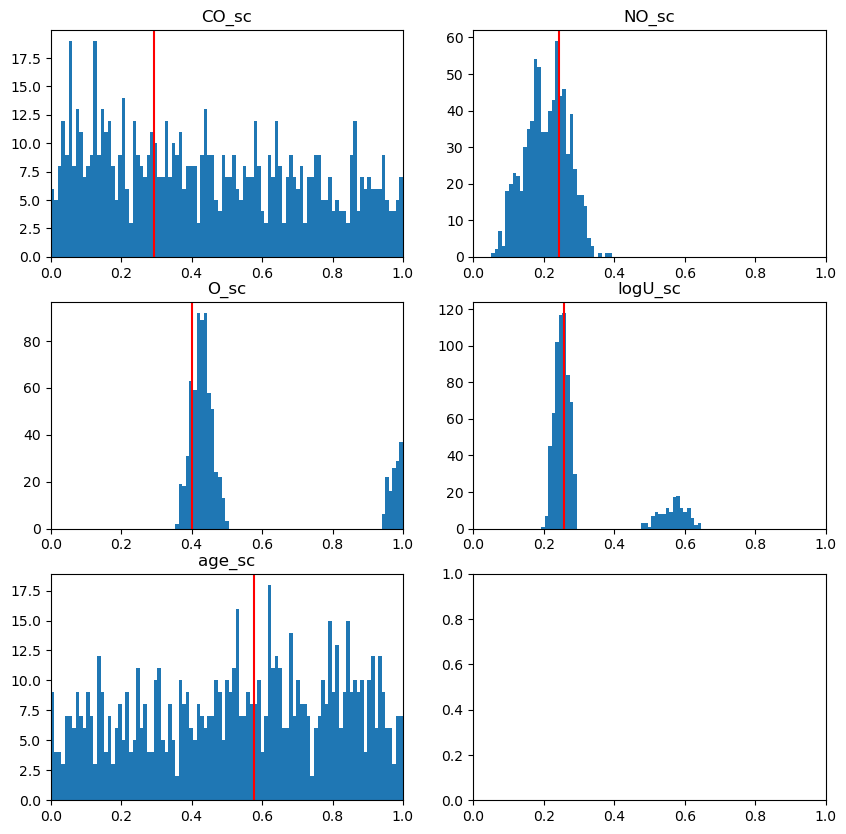

In [53]:
# The list of lines to be used to find parameters that approach the "target".
#diff_str = ['O3', 'N2', 'O2', 'Ar3', 'Ne3', 'He1']
diff_str = ['O3', 'N2', 'O2', 'rO3']
preds['mean'] = np.mean(np.abs((preds[diff_str] - target[diff_str])), 1)
preds['max'] = np.max(np.abs((preds[diff_str] - target[diff_str])), 1)
# We select the models that have a mean difference less than 0.15
best_diffs_loc = preds['mean'] < 0.15
print(best_diffs_loc.sum())
# We will plot the distributions of the parameters of the models that reproduce the observations.
f, axes = plt.subplots(3,2, figsize=(10,10))
for k, ax in zip(X_str_sca, axes.ravel()):
    ax.hist(P.loc[best_diffs_loc, k], bins=np.linspace(0,1,100))
    ax.set_xlim(0,1)
    ax.set_title(k)
    ax.axvline(target[k], c='red')

776


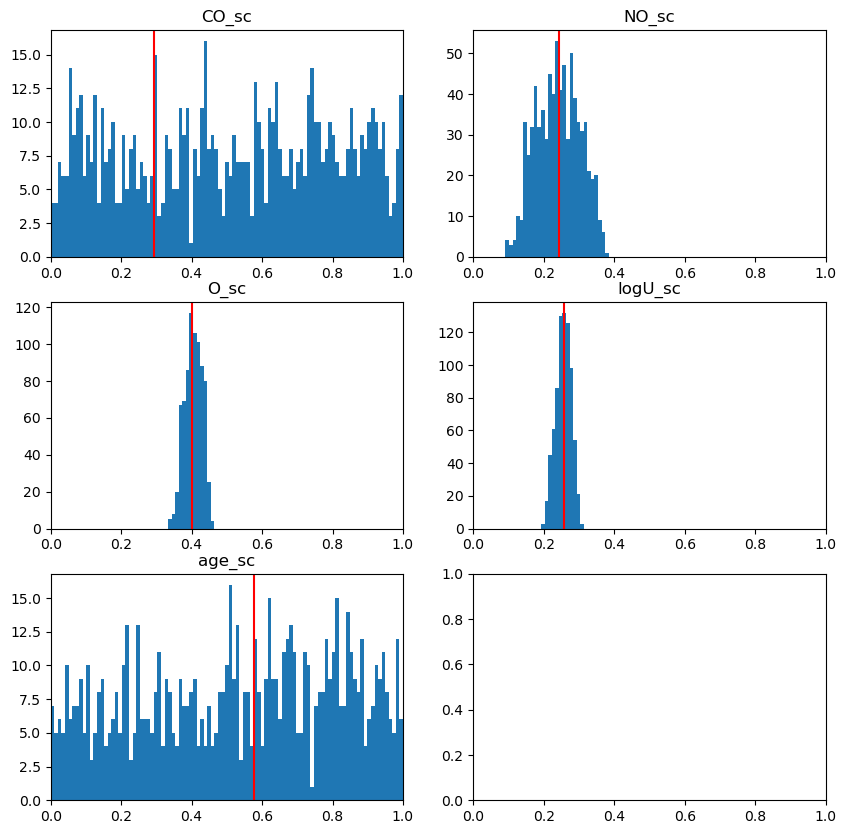

In [54]:
# The list of lines to be used to find parameters that approach the "target".
diff_str = ['O3', 'N2', 'O2', 'Ar3', 'Ne3', 'He1', 'rO3']
preds['mean'] = np.mean(np.abs((preds[diff_str] - target[diff_str])), 1)
preds['max'] = np.max(np.abs((preds[diff_str] - target[diff_str])), 1)
# We select the models that have a mean difference less than 0.15
best_diffs_loc = preds['mean'] < 0.15
print(best_diffs_loc.sum())
# We will plot the distributions of the parameters of the models that reproduce the observations.
f, axes = plt.subplots(3,2, figsize=(10,10))
for k, ax in zip(X_str_sca, axes.ravel()):
    ax.hist(P.loc[best_diffs_loc, k], bins=np.linspace(0,1,100))
    ax.set_xlim(0,1)
    ax.set_title(k)
    ax.axvline(target[k], c='red')